In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2, f_classif

In [3]:
# i.) Loading the dataset
df = pd.read_csv('loan/loan_approval_dataset.csv')

# Data Cleaning: Remove leading spaces from column names
df.columns = df.columns.str.strip()

# ii.) Exploratory Data Analysis and Visualization

# Summary Statistics
print("Summary Statistics:")
print(df.describe())

Summary Statistics:
           loan_id  no_of_dependents  income_annum   loan_amount    loan_term  \
count  4269.000000       4269.000000  4.269000e+03  4.269000e+03  4269.000000   
mean   2135.000000          2.498712  5.059124e+06  1.513345e+07    10.900445   
std    1232.498479          1.695910  2.806840e+06  9.043363e+06     5.709187   
min       1.000000          0.000000  2.000000e+05  3.000000e+05     2.000000   
25%    1068.000000          1.000000  2.700000e+06  7.700000e+06     6.000000   
50%    2135.000000          3.000000  5.100000e+06  1.450000e+07    10.000000   
75%    3202.000000          4.000000  7.500000e+06  2.150000e+07    16.000000   
max    4269.000000          5.000000  9.900000e+06  3.950000e+07    20.000000   

       cibil_score  residential_assets_value  commercial_assets_value  \
count  4269.000000              4.269000e+03             4.269000e+03   
mean    599.936051              7.472617e+06             4.973155e+06   
std     172.430401             

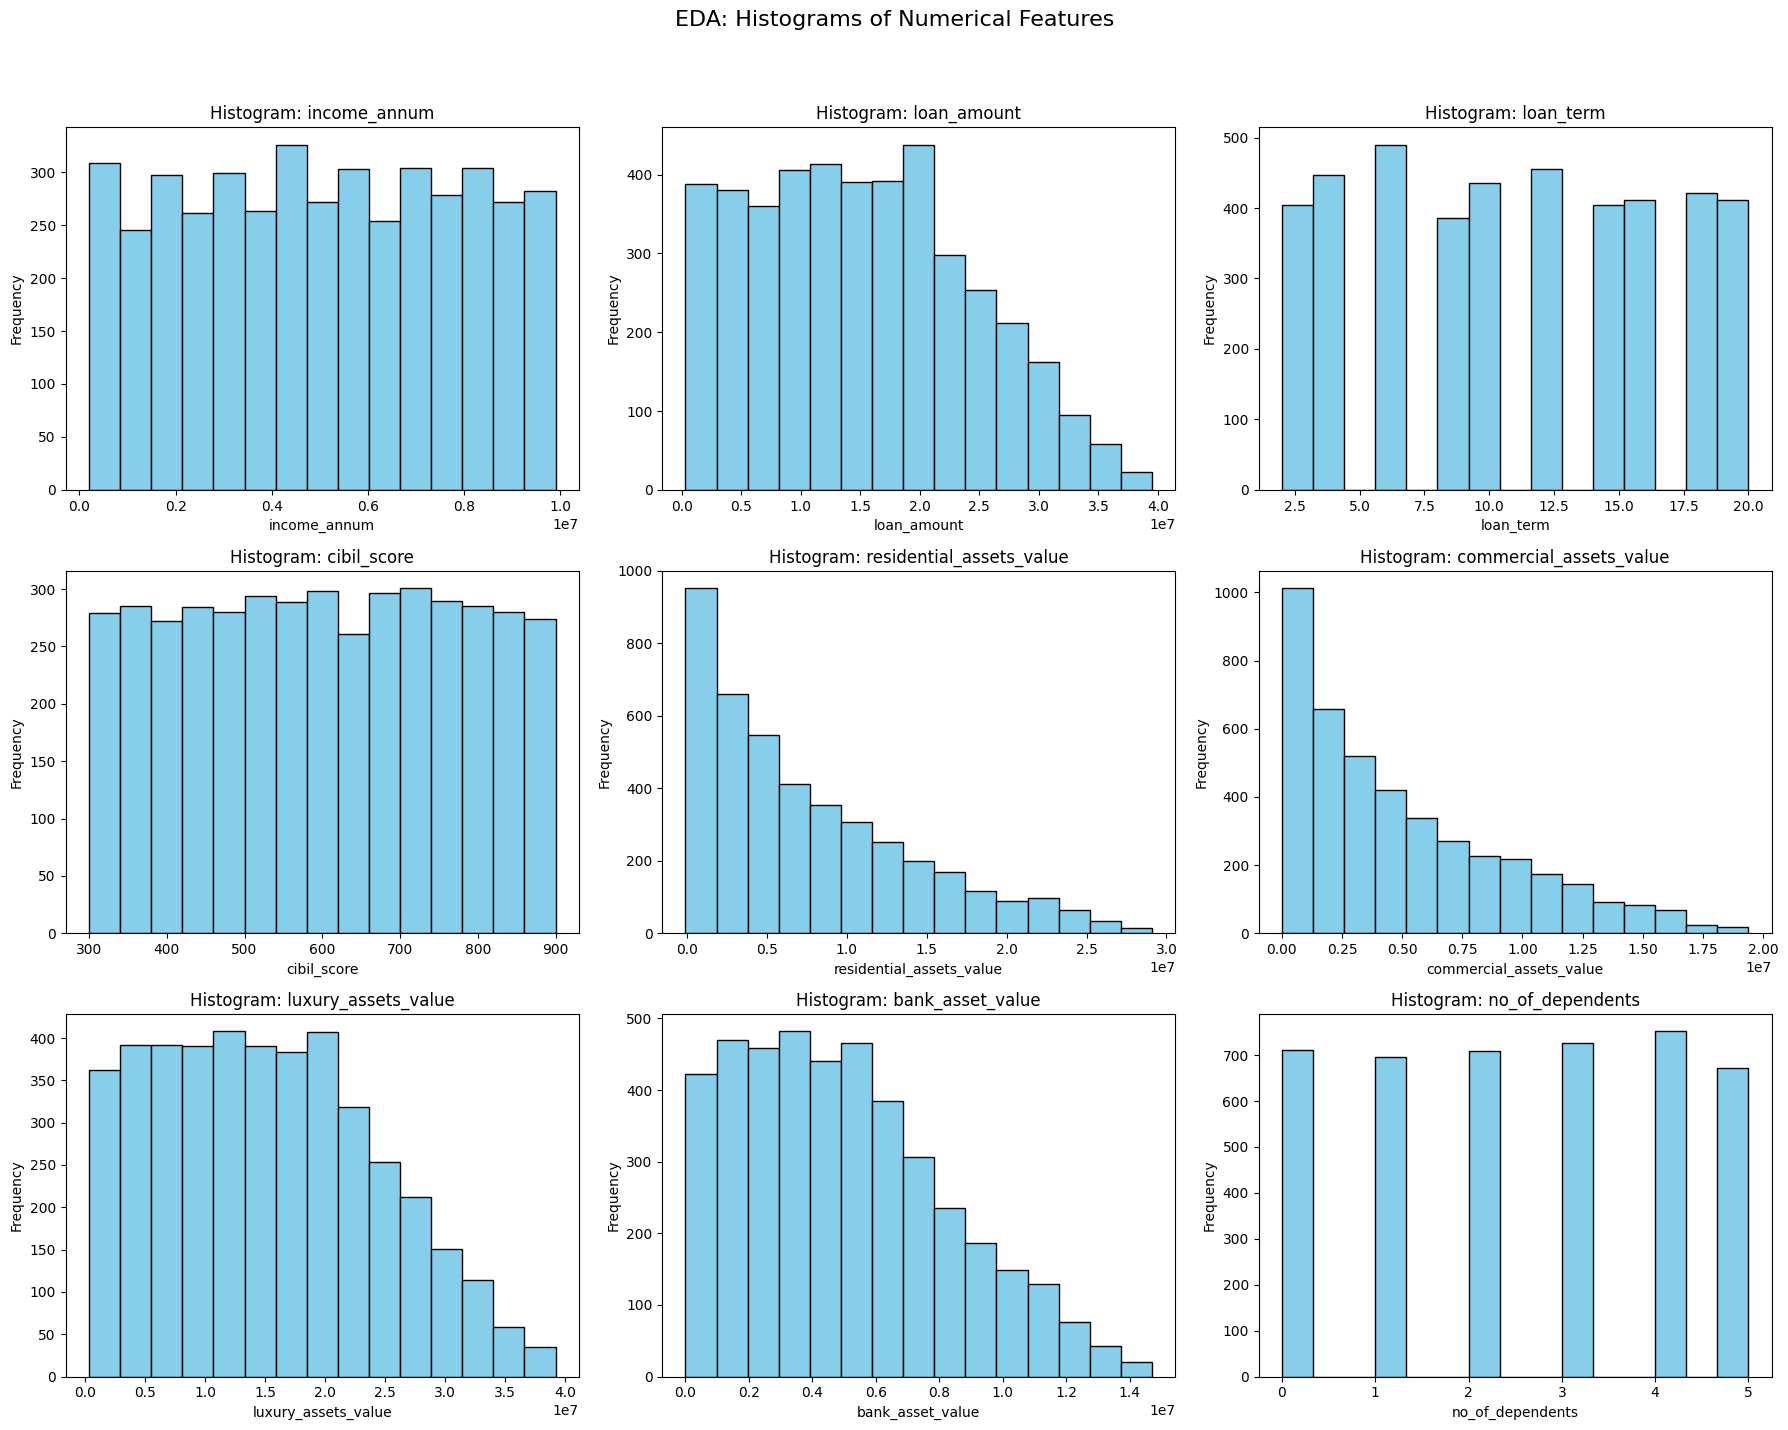

In [4]:
# Define feature groups
numeric_features = ['income_annum', 'loan_amount', 'loan_term', 'cibil_score', 
                    'residential_assets_value', 'commercial_assets_value', 
                    'luxury_assets_value', 'bank_asset_value', 'no_of_dependents']
categorical_features = ['education', 'self_employed', 'loan_status']

# Grid 1: Histograms (3x3 Grid, Width 1)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('EDA: Histograms of Numerical Features', fontsize=16)
axes_flat = axes.flatten()

for i, feature in enumerate(numeric_features):
    ax = axes_flat[i]
    # rwidth=1.0 ensures bars touch
    ax.hist(df[feature], bins=15, color='skyblue', edgecolor='black', rwidth=1.0)
    ax.set_title(f'Histogram: {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# Code to save as EPS
plt.savefig('loan_histograms.eps', format='eps')
plt.show()

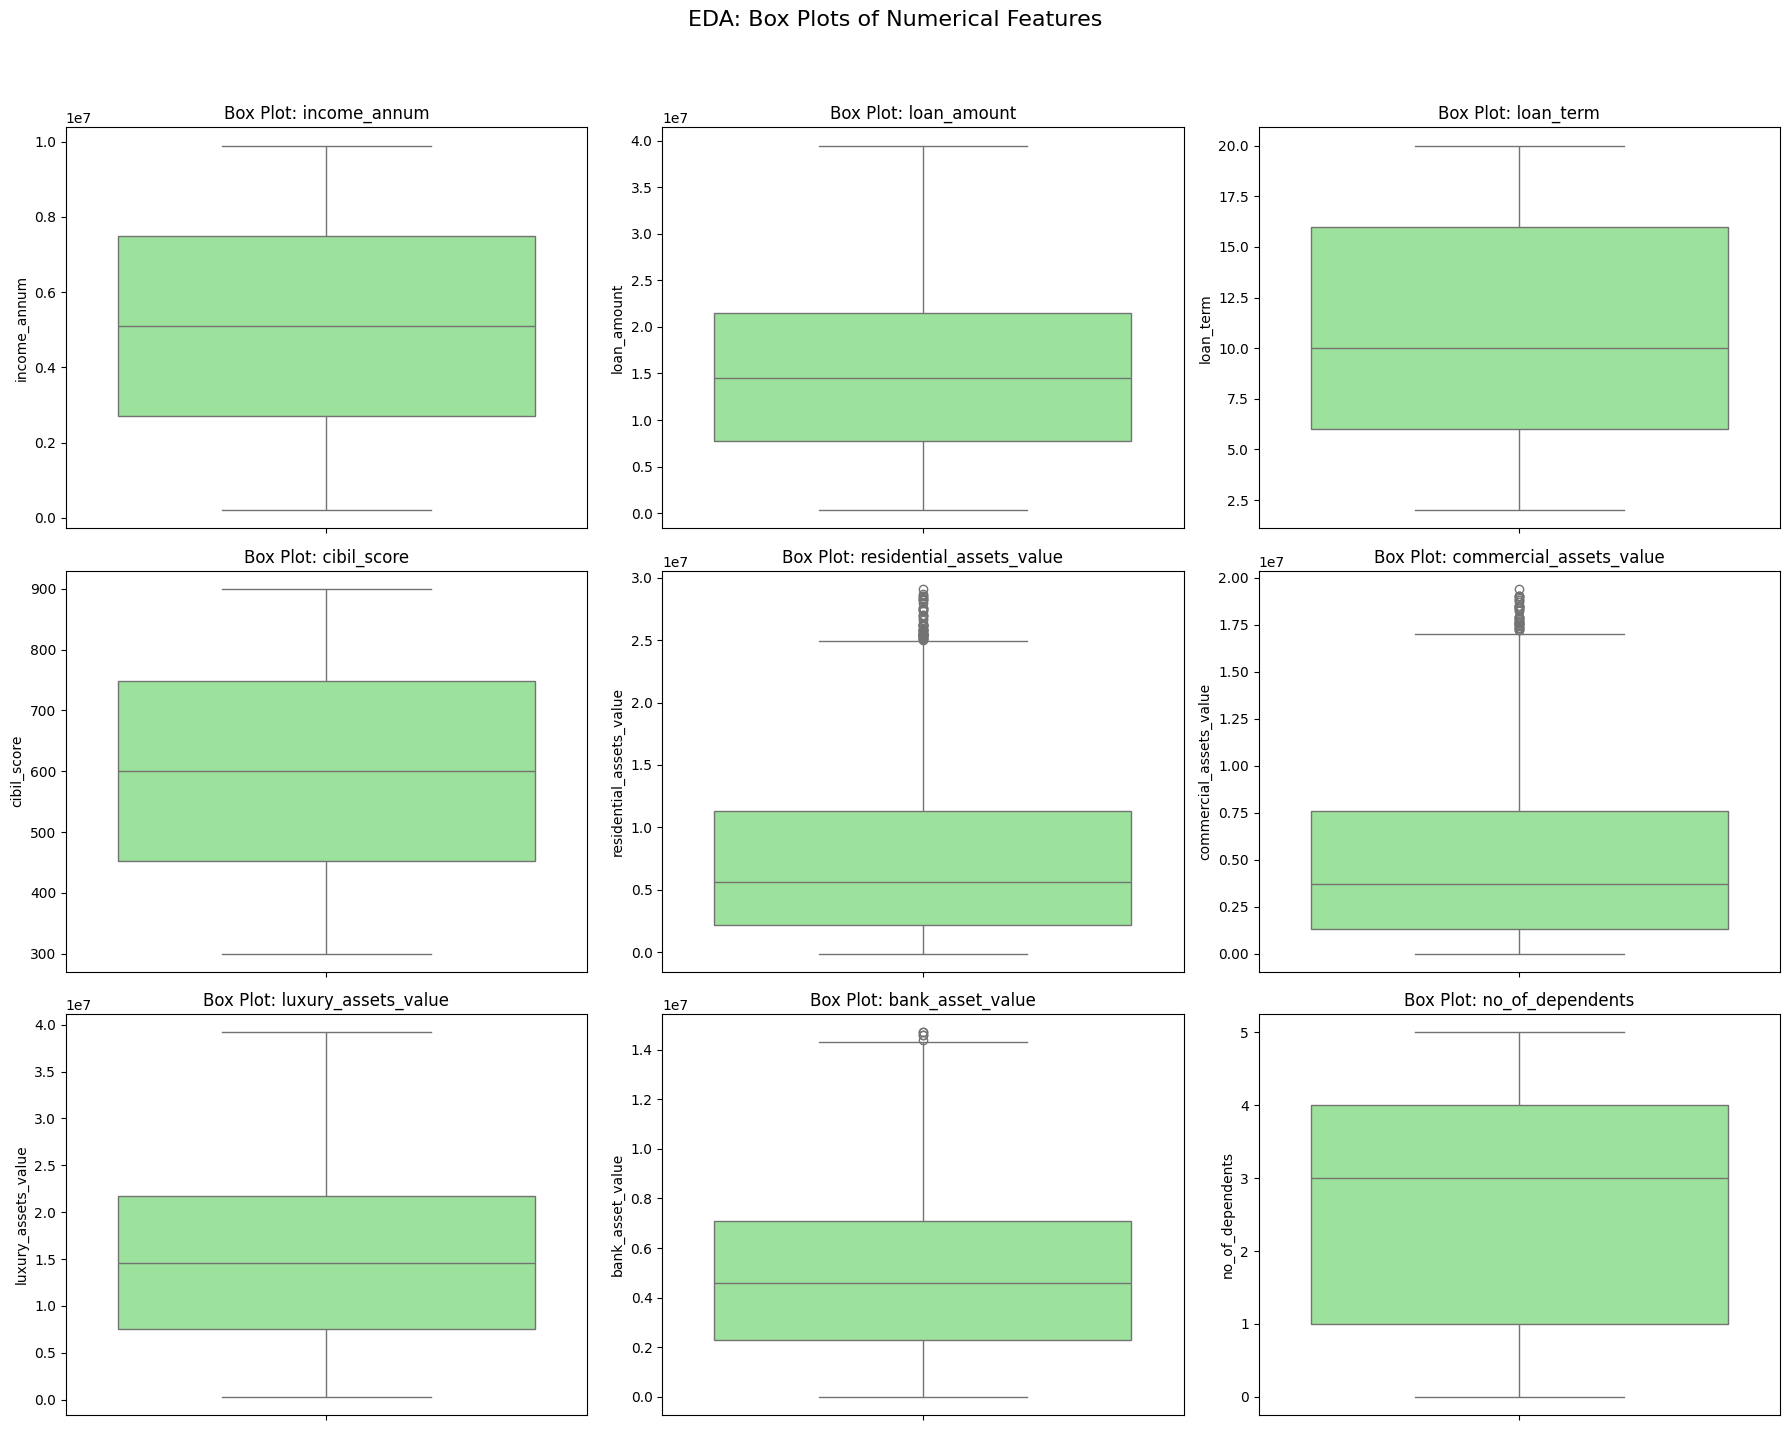

In [5]:
# Grid 2: Box Plots (3x3 Grid)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('EDA: Box Plots of Numerical Features', fontsize=16)
axes_flat = axes.flatten()

for i, feature in enumerate(numeric_features):
    ax = axes_flat[i]
    sns.boxplot(y=df[feature], ax=ax, color='lightgreen')
    ax.set_title(f'Box Plot: {feature}')
    ax.set_ylabel(feature)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('loan_boxplots.eps', format='eps')
plt.show()

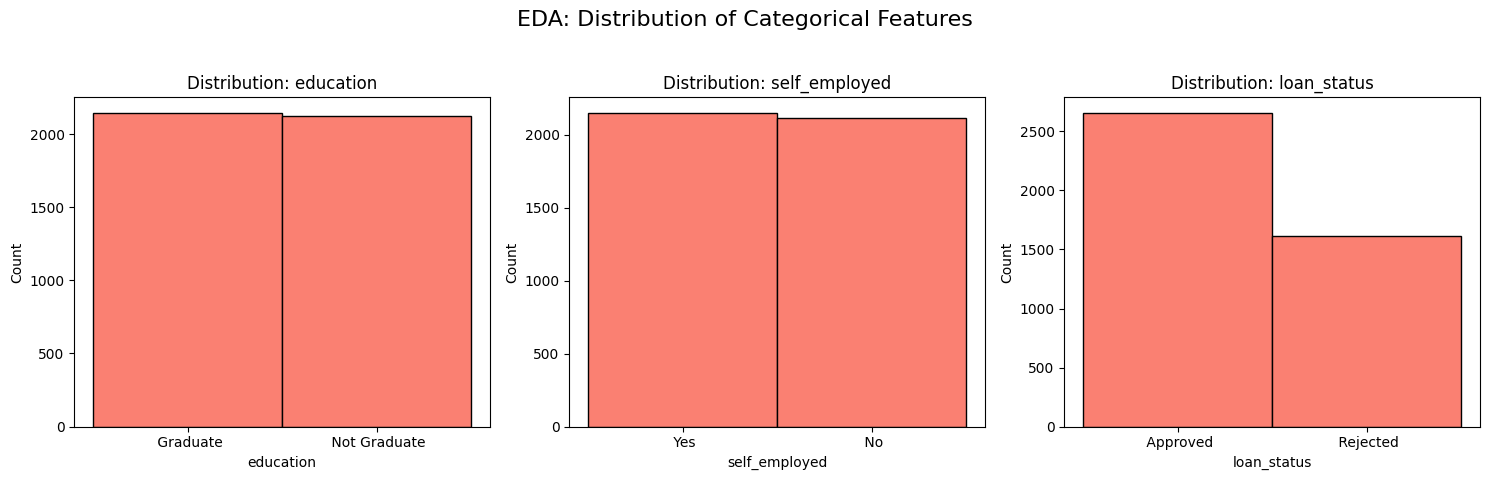

In [6]:
# Grid 3: Categorical Bar Charts (1x3 Grid, Width 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('EDA: Distribution of Categorical Features', fontsize=16)

for i, feature in enumerate(categorical_features):
    ax = axes[i]
    counts = df[feature].value_counts()
    # width=1.0 ensures bars touch
    ax.bar(counts.index, counts.values, width=1.0, color='salmon', edgecolor='black')
    ax.set_title(f'Distribution: {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('loan_categorical.eps', format='eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


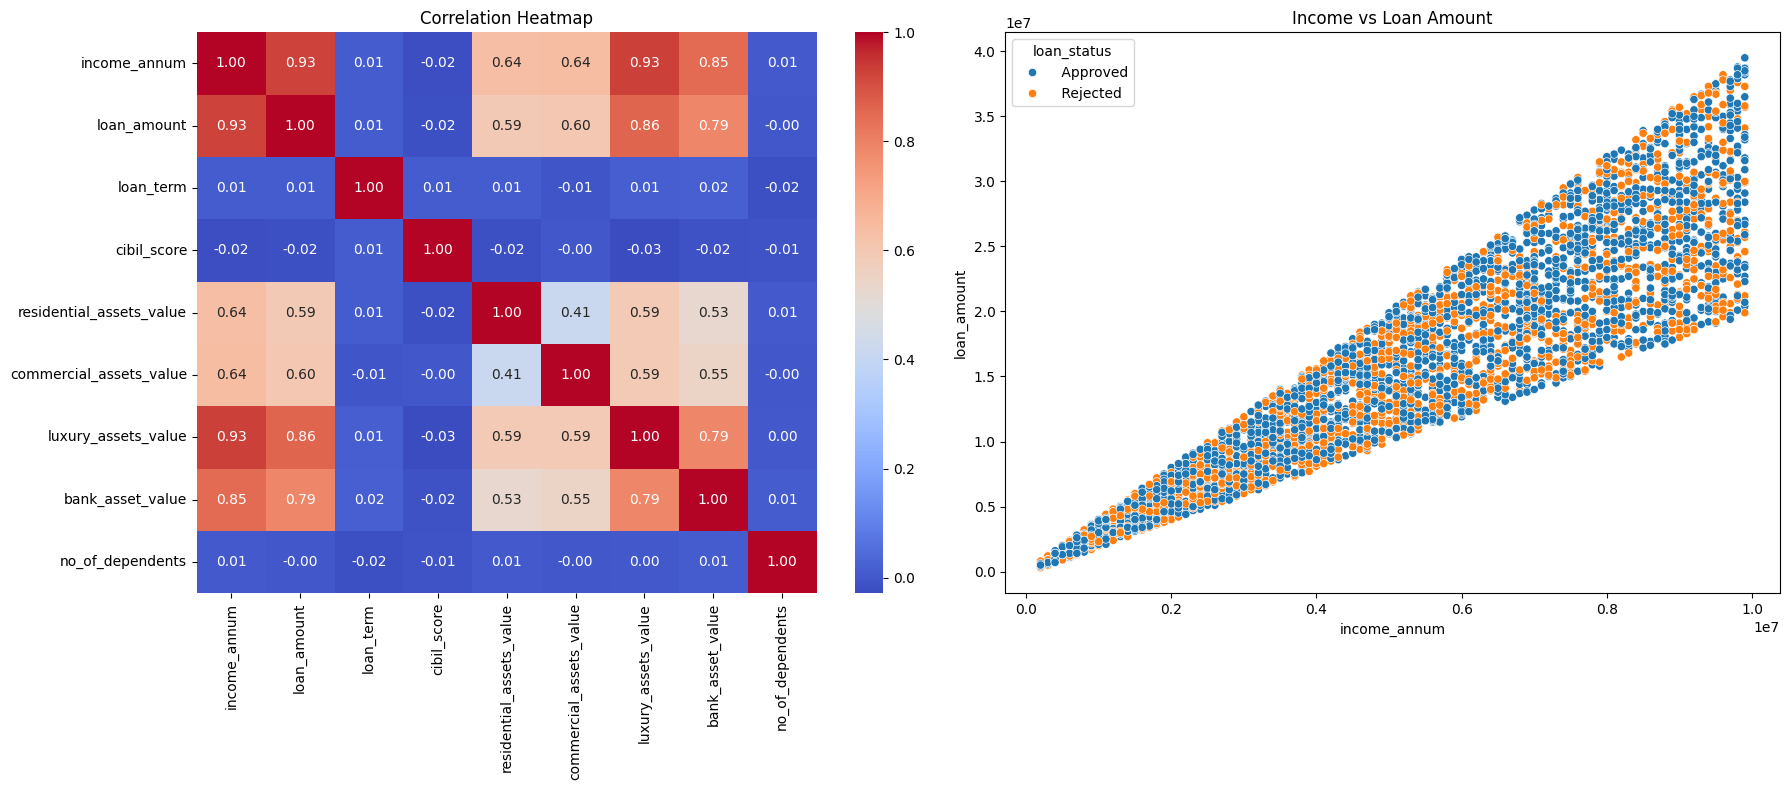

In [7]:
# Grid 4: Heatmap & Scatter (1x2 Grid)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Heatmap (Numeric Features Only)
numeric_corr_df = df[numeric_features]
sns.heatmap(numeric_corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title('Correlation Heatmap')

# Scatter Plot
sns.scatterplot(x='income_annum', y='loan_amount', hue='loan_status', data=df, ax=axes[1])
axes[1].set_title('Income vs Loan Amount')

plt.tight_layout()
plt.savefig('loan_bivariate.eps', format='eps')
plt.show()

In [8]:
# iii.) Data Preprocessing

# Handle missing values
df.dropna(inplace=True)

# Drop irrelevant features
if 'loan_id' in df.columns:
    df = df.drop('loan_id', axis=1)

# Encode categorical variables
le = LabelEncoder()
df_encoded = df.copy()
for col in categorical_features:
    df_encoded[col] = le.fit_transform(df[col])

# Separate Features (X) and Target (y)
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# Standardize/Normalize
# For ANOVA and Splitting (StandardScaler)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
X_std_df = pd.DataFrame(X_std, columns=X.columns)

# For Chi-Square (MinMaxScaler to ensure non-negative values)
minmax = MinMaxScaler()
X_minmax = minmax.fit_transform(X)
X_minmax_df = pd.DataFrame(X_minmax, columns=X.columns)

In [9]:
# iv.) Feature Selection

# 1. Chi-square Test (Using MinMaxScaler Data)
print("\n--- Chi-square Test Results ---")
chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_minmax_df, y)
chi2_scores = pd.DataFrame({'Feature': X.columns, 'Score': chi2_selector.scores_})
print(chi2_scores.sort_values(by='Score', ascending=False))

# 2. ANOVA (Using Standardized Data)
print("\n--- ANOVA Results ---")
anova_selector = SelectKBest(score_func=f_classif, k='all')
anova_selector.fit(X_std_df, y)
anova_scores = pd.DataFrame({'Feature': X.columns, 'Score': anova_selector.scores_})
print(anova_scores.sort_values(by='Score', ascending=False))


--- Chi-square Test Results ---
                     Feature       Score
6                cibil_score  418.637526
5                  loan_term   11.094830
0           no_of_dependents    0.322398
7   residential_assets_value    0.168504
3               income_annum    0.164588
4                loan_amount    0.156561
9        luxury_assets_value    0.146679
8    commercial_assets_value    0.057941
1                  education    0.051854
10          bank_asset_value    0.028317
2              self_employed    0.000251

--- ANOVA Results ---
                     Feature        Score
6                cibil_score  6235.054591
5                  loan_term    55.225458
0           no_of_dependents     1.400600
4                loan_amount     1.113176
9        luxury_assets_value     1.020728
3               income_annum     0.984669
7   residential_assets_value     0.880877
8    commercial_assets_value     0.290152
10          bank_asset_value     0.196066
1                  education    

In [10]:
# v.) Data Splitting
# 70% Train, 15% Val, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(X_std, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("\n--- Data Splitting Shapes ---")
print(f"Train set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")


--- Data Splitting Shapes ---
Train set: (2988, 11)
Validation set: (640, 11)
Test set: (641, 11)
